`exorings` - Phase curve comparison
###### <p style="line-height: 5%;">[@snhasler](https://github.com/snhasler/exorings/tree/main)</p>


##### This is an example notebook to illustrate plotting the combined phase curve files so the user can swap out any file they would like for comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.insert(1, '../')
import utils

In [2]:
# Set some parameters for plotting
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({"font.size": 14})

In [3]:
# Set path to files
file_dir = "/Users/shasler/Documents/Projects/Roman/fraction_lit_output/for_paper/1xSat_obl26.73_varyingIncl/"

# Pick your file(s) of choice for plotting
file1_i90_obl27 = "combined_phasecurve_e0.0_inc90.0deg_obliq26.73deg_72707.44Rring_250epochs_BAND1_BringOnly_Lambertianplanet.txt"

In [4]:
# Read in combined phase curve to a dataframe
df_phasecurve_1xSat = pd.read_csv(file_dir + file1_i90_obl27)

# Sort dfs by true anomaly value (important to ensure the phase curves are in order for plotting)
true_anom_sorted, fpfs_sorted, sorted_ids = utils.sort_trueanom_flux(df_phasecurve_1xSat)

##### To compare this ringed planet to a ringless Lambertian planet of the same radius and separation, we can estimate the phase curve with:

$ \frac{F_p}{F_s} = A_g * \Phi * (\frac{R_p}{a} )^2 $

where $A_g$ is the geometric albedo, $\Phi$ is the phase function (in this case, Lambertian), $R_p$ is the planet radius, and $a$ is the separation.

In [9]:
AU_to_km = 1.496e8  # convert AU to km
Ag = 0.5            # planet's geometric albedo in your filter of choice
rp_over_a_sq = (69911 / (5.2 * AU_to_km)) ** 2
scale = Ag * rp_over_a_sq

# Sort phase angles
phase_angles_sorted = df_phasecurve_1xSat["phase_angle"].iloc[sorted_ids]

ringless = scale * utils.phi_lambert(phase_angles_sorted)

##### Plotting time:

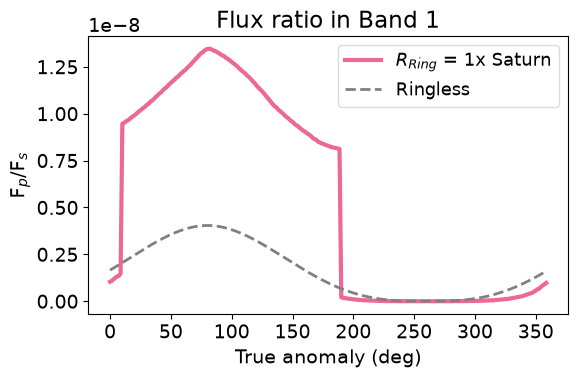

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(true_anom_sorted, fpfs_sorted, label="$R_{Ring}$ = 1x Saturn", color="#ed6892", lw=3)
ax.plot(true_anom_sorted, ringless, label='Ringless', color='gray', ls='dashed', lw=2)

ax.set_xlabel("True anomaly (deg)")
ax.set_ylabel("F$_p$/F$_s$")
ax.set_title("Flux ratio in Band 1")
ax.legend(loc='upper right', framealpha=0.7, fontsize=13)

plt.tight_layout()
plt.show()